# BUCSS 2026
## AI Session Hands-On Part 1: Data Insights and Pre-processing

In this notebook you will:
- Load observational data from weather station networks of different cities
- Visualize observations
- Prepare data sets for training (next part, different notebook)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmcrameri.cm as cmc

#These are internal
from scripts.dataprep import load_data, build_station_predictors, coarsen_raster, load_era5land, deaccumulate, transform_met
from scripts.plotting import obs_map, week_plot, quick_raster_plot

First, let's decide which city you want to extract your data from:

In [23]:
city = "ghent"
country = "belgium"
data = load_data(city) #options are "bern", "dortmund", "freiburg", "ghent"

# print(data) #you can check out how we load the data in ../scripts/dataprep.py 
# this returns a basic dataframe with a station id, coordinates, datetime of the measurement and the
# measured value in °C
 


loading pre-existing dataframe


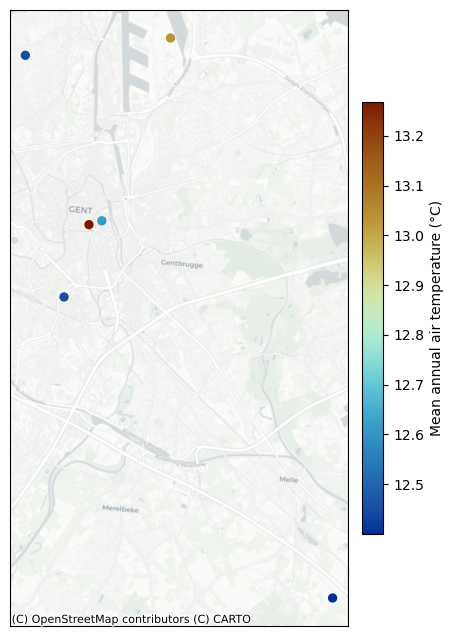

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [24]:
# We can do a basic map to display where the measurements took place, with circles colored by their average temperature

# we take the mean observed temperature for each station and in so doing collapse the datafame
# to one row per station
stn = (data.groupby("station_id")
            .agg(longitude=("longitude", "first"),
                    latitude=("latitude", "first"),
                    tmean=("air_temperature", "mean"))
            .reset_index())

obs_map(stn, value_col = "tmean")

Let's see how a typical diurnal cycle would look for the hottest and coldest stations, in the hottest week of summer.

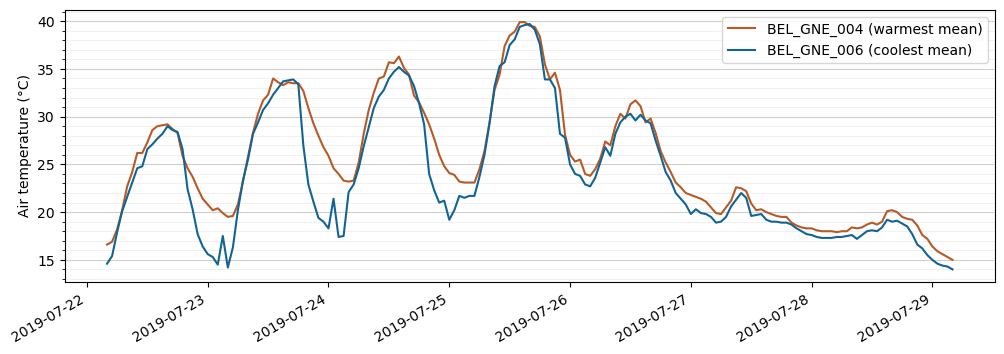

(<Figure size 1200x400 with 1 Axes>, <Axes: ylabel='Air temperature (°C)'>)

In [25]:
# find the time with the absolute hottest temperature measured
hottest_time = data.loc[data["air_temperature"].idxmax(), "datetime_utc"]

# we set up a time window that is a week long, centered around the hottest time
half = pd.Timedelta(days=3.5)
lo, hi = hottest_time - half, hottest_time + half
window = data["datetime_utc"].between(lo, hi)

# filter to stations that have data during this hot week
in_window = data[window]

# observation count per station within the window
counts = in_window.groupby("station_id")["datetime_utc"].count()

# keep stations with >= 70% of the best-covered station's count
threshold = 0.5 * counts.max()
present_ids = counts[counts >= threshold].index

# mean temp per WELL-COVERED station during the window
stn = (in_window[in_window["station_id"].isin(present_ids)]
           .groupby("station_id")["air_temperature"].mean()
           .rename("tmean").reset_index())

hot_id  = stn.loc[stn["tmean"].idxmax(), "station_id"]
cold_id = stn.loc[stn["tmean"].idxmin(), "station_id"]

hot_week  = data[(data["station_id"] == hot_id)  & window].sort_values("datetime_utc")
cold_week = data[(data["station_id"] == cold_id) & window].sort_values("datetime_utc")

week_plot(hot_week, cold_week, hot_id, cold_id)

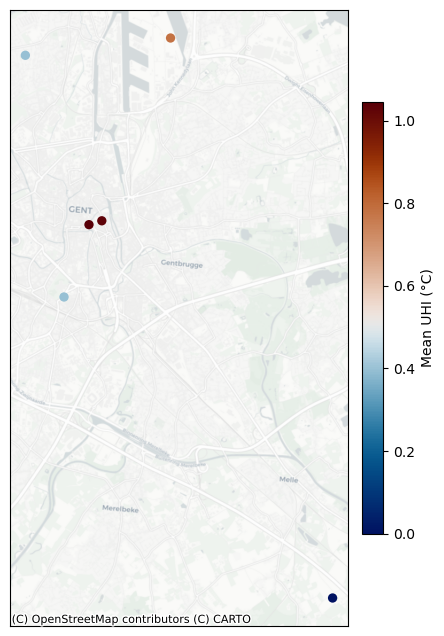

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [26]:

stn = (data.groupby("station_id")
            .agg(longitude=("longitude", "first"),
                    latitude=("latitude", "first"),
                    tmean=("air_temperature", "mean"))
            .reset_index())

rural_id = stn.loc[stn["tmean"].idxmin(), "station_id"]


rural = (data.loc[data["station_id"] == rural_id, ["datetime_utc", "air_temperature"]]
             .rename(columns={"air_temperature": "t_rural"}))

m = data.merge(rural, on="datetime_utc", how="inner")

m["uhi"] = m["air_temperature"] - m["t_rural"]

uhi = m.groupby("station_id")["uhi"].mean().reset_index(name="uhi_mean")

uhi = uhi.merge(stn[["station_id", "longitude", "latitude"]], on="station_id")

obs_map(uhi, value_col = "uhi_mean")

Why are the Bern values so high ? Let's take a closer look at what time period they cover:

In [27]:
print(data["datetime_utc"].min())
print(data["datetime_utc"].max())

2016-07-01 00:00:00+00:00
2023-10-12 06:00:00+00:00


Maybe that's not enough, let's make a histogram that displays the number of observations per month:

/scratch/local/12145059/ipykernel_2682116/4036120785.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months = data["datetime_utc"].dt.to_period("M")


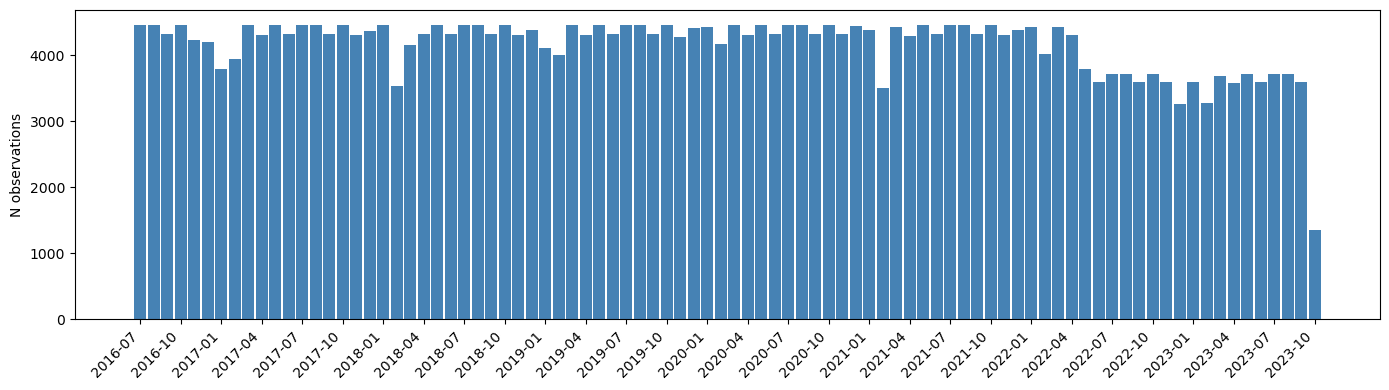

(<Figure size 1400x400 with 1 Axes>, <Axes: ylabel='N observations'>)

In [28]:
def obs_per_month(data: pd.DataFrame):
    #group the data per month
    months = data["datetime_utc"].dt.to_period("M")

    # count observations per calendar month
    counts = months.value_counts().sort_index()

    # build the FULL month range and reindex -> missing months become 0
    full = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
    counts = counts.reindex(full, fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(counts.index.astype(str), counts.values, width=0.9, color="steelblue")
    ax.set_ylabel("N observations")

    # thin the x labels so they don't collide
    step = max(1, len(counts) // 24)
    ax.set_xticks(range(0, len(counts), step))
    ax.set_xticklabels([str(counts.index[i]) for i in range(0, len(counts), step)],
                       rotation=45, ha="right")
    fig.tight_layout()
    plt.show()
    return fig, ax

obs_per_month(data)

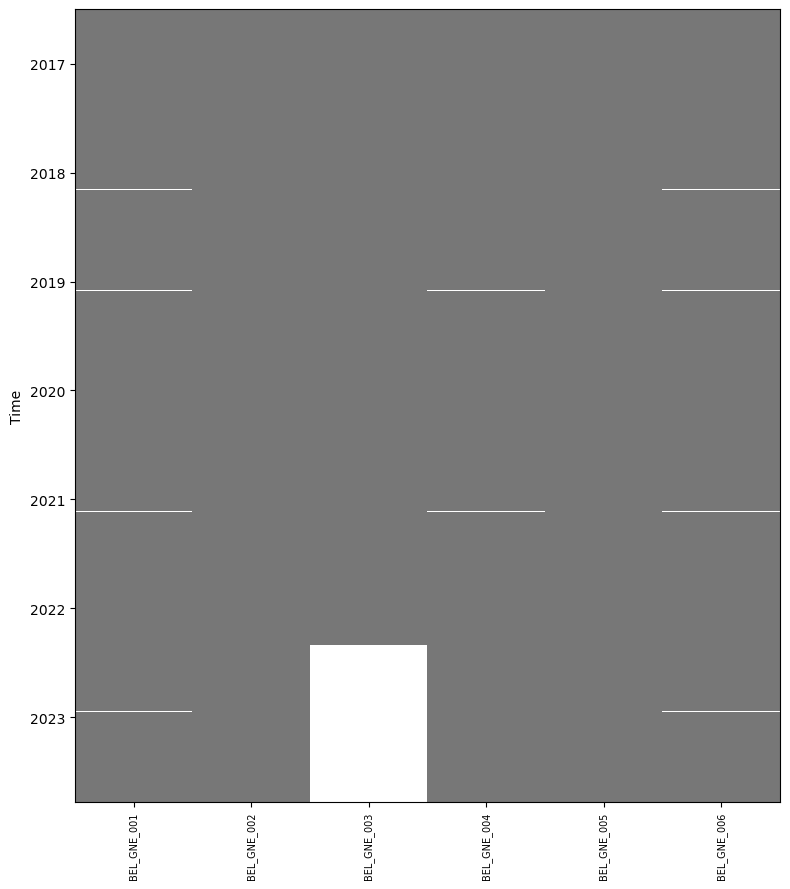

(<Figure size 800x900 with 1 Axes>, <Axes: ylabel='Time'>)

In [29]:
def availability(data: pd.DataFrame, freq="D"):
    # sort stations by ID instead of date
    stations = sorted(data["station_id"].unique())

    # get the time axis on which observations are given
    t0 = data["datetime_utc"].min().floor(freq)
    t1 = data["datetime_utc"].max().floor(freq)

    #slots that are available to be plotted according to the desired frequency (daily by default)
    slots = pd.date_range(t0, t1, freq=freq, tz="UTC")

    fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(stations)), 9))

    #we initialize an empty grid to fill the data availability with
    grid = np.full((len(slots), len(stations)), np.nan)
    # j = counter, sid = station id
    for j, sid in enumerate(stations):
        # which slots does this station have any obs in?
        s = data.loc[data["station_id"] == sid, "datetime_utc"]
        # bin this station's obs onto the SAME slots via floor, then mark hits
        binned = s.dt.floor(freq)
        
        # this will bin any number of hourly observations to the same day
        hit = pd.Series(True, index=binned).groupby(level=0).any()

        # we re-align this station's observational span to the span of the entire series and do not fill empty values
        hit = hit.reindex(slots, fill_value=False)

        # fill the grid with 1 when we have observations
        grid[hit.values, j] = 1.0 

    one_gray = ListedColormap([cmc.grayC(0.5)])    
    # use pcolormesh method for gridded data
    ax.pcolormesh(np.arange(len(stations)), slots, grid,
                  cmap=one_gray, vmin=0, vmax=1, shading="nearest")

    ax.set_xticks(np.arange(len(stations)))          # 0,1,2,... = cell centers
    ax.set_xticklabels(stations, rotation=90, fontsize=7)
    ax.set_ylabel("Time")
    ax.invert_yaxis()          # earliest at top, latest at bottom
    fig.tight_layout()
    plt.show()
    return fig, ax

availability(data)

# Raster data
Okay now that we have clean data and we know what it looks like, we can start processing the predictors we might need.

In [1]:
quick_raster_plot(city,"terrain") #options are all 4 cities, buildings, tcd, lcz, terrain

NameError: name 'quick_raster_plot' is not defined

We need to process all of this data to the same standard, and decide which resolution we want to work with. 

In [31]:
base_path = "../data/"
target_resolution = 50
coarsen_raster(base_path + "dtm/bern_30.tif", base_path + f"dtm/bern_{target_resolution}_coarsened.tif", target_resolution)

current pixel size is 30.0, 30.0


At this point, we need to decide which resolution we will be working with... If we want to work at the base resolution, the rasters can stay as is, otherwise we should coarsen them to the desired resolution and then proceed.

## Adding the raster data to our data frames
The shallow ML and statistical models we are reviewing require dataframes for training, as opposed to e.g. a convolutional neural network (CNN) which would require image data, in which case the rasters would be left as is. Instead, we need to assign to our point measurements a value issued from the rasters by obtaining the raster data from the nearest cell neighbour to the measurements.Luckily, rasterio has just the thing for us:

In [32]:
# --- usage ---
raster_paths = {
    "bh":  f"../data/bh/{city}_10.tif",
    "tcd": f"../data/tcd/{city}_10.tif",
    "imp": f"../data/imp/{city}_10.tif",
}
station_predictors = build_station_predictors(data, raster_paths)

# merge on station_id copies all of the geospatial data from station_id to all instances of station_id in the original dataframe
data = data.merge(station_predictors.drop(columns=["latitude", "longitude", "x", "y"]),
              on="station_id", how="left")



        

a station in bh is out of bounds


In [33]:
single_paths = {
    "dtm":  f"../data/dtm/{city}_30.tif",
    "lcz": f"../data/lcz/{city}_100.tif",
}
single_predictors = build_station_predictors(data, single_paths, radii=())

data = data.merge(single_predictors.drop(columns=["latitude", "longitude", "x", "y"]),
              on="station_id", how="left")

In [34]:
data = data.dropna()

In [35]:
def onehot_lcz(df, col="lcz_nearest", prefix="LCZ", n_classes=17):
    """Turn lcz_nearest (float class code) into LCZ_1..LCZ_17 one-hot columns."""
    lcz_type = df[col].round().astype("Int64")     # 5.0 -> 5, nullable int keeps NaN

    for k in range(1, n_classes + 1):
        df[f"{prefix}_{k}"] = (lcz_type == k).astype("int8")

    return df

data = onehot_lcz(data, col="lcz_nearest")

In [36]:
# pick one station's first row (any timestamp works — geo predictors are time-invariant)
stations = data["station_id"].unique()
sid = stations[1]        # change this index: 0, 1, 2, ... = different stations
row = data[data["station_id"] == sid].iloc[0]

# the columns we added (everything from the rasters)
geo_cols = [c for c in data.columns
            if c not in ("station_id",
                         "datetime_utc", "air_temperature")]

print(f"Station: {sid}")
print(f"Timestamp: {row['datetime_utc']}")
for c in geo_cols:
    print(f"  {c:20s} {row[c]}")

Station: BEL_GNE_006
Timestamp: 2016-07-01 00:00:00+00:00
  latitude             50.98
  longitude            3.816
  bh_nearest           0.0
  bh_buf50             0.0
  bh_buf100            0.0
  bh_buf250            0.0
  bh_buf500            0.0
  bh_buf750            0.0
  bh_buf1000           0.0
  tcd_nearest          0.0
  tcd_buf50            0.0
  tcd_buf100           0.0
  tcd_buf250           0.0
  tcd_buf500           1.4633524417877197
  tcd_buf750           4.698782920837402
  tcd_buf1000          7.374606132507324
  imp_nearest          0.0
  imp_buf50            0.0
  imp_buf100           1.561514139175415
  imp_buf250           4.520142555236816
  imp_buf500           7.897769451141357
  imp_buf750           5.912029266357422
  imp_buf1000          6.603271961212158
  dtm_nearest          12.300000190734863
  lcz_nearest          14.0
  LCZ_1                0
  LCZ_2                0
  LCZ_3                0
  LCZ_4                0
  LCZ_5                0
  LCZ_6  

For LCZs : one-hot-encode or leave out

for DTM: TPI is the only that would make sense

## Meteorological data from ERA5-Land

We need to process netcdf4 files with xarray:

In [37]:
# city center coords for ERA5-Land nearest-cell selection
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="get_cc_coords")

location = geolocator.geocode(city + "," + country)

lat0, lon0 = location.latitude, location.longitude

print(lat0, lon0)



51.0538286 3.7250121


In [38]:
# obtain what days our data is measured over
needed = data["datetime_utc"].dt.strftime("%Y-%m-%d").unique()   
met, era5_elev = load_era5land(f"../../raw_data/era5land/",
                               f"../../raw_data/era5land/geopotential.nc",
                               lat0, lon0, needed_dates=needed)




ERA5-Land (2660 days): 100%|██████████| 2660/2660 [14:11<00:00,  3.12it/s]


In [39]:
met = deaccumulate(met, "ssrd")                                                  # 3
met = deaccumulate(met, "tp")
met = transform_met(met)                                                         # 4



In [40]:
before = len(data)

# finally, we broadcast all hourly values to all stations since we give the same forcing for all stations
data = data.merge(met, on="datetime_utc", how="left")                           # 5
assert len(data) == before, "met merge changed row count — duplicate timestamps"

# elevation corrected t2m is station-dependent, so we add this predictor at the end
data["t2m_corr"] = data["t2m"] - 0.0065 * (data["dtm_nearest"] - era5_elev)    

In [41]:
# sanity check 

cols = ["station_id", "datetime_utc",
        "t2m", "t2m_corr", "d2m", "rh",
        "tp", "tp_deac", "ssrd", "ssrd_deac"]

print(data[cols].head(20).to_string(index=False))

 station_id              datetime_utc       t2m  t2m_corr       d2m        rh           tp      tp_deac      ssrd  ssrd_deac
BEL_GNE_001 2016-07-01 00:00:00+00:00 16.015778 15.995594 13.774811 86.554794 3.602797e-03          NaN 8342356.0        NaN
BEL_GNE_001 2016-07-01 01:00:00+00:00 16.216461 16.196278 14.030670 86.885193 9.238720e-07 9.238720e-07       0.0        0.0
BEL_GNE_001 2016-07-01 02:00:00+00:00 16.699860 16.679676 14.359528 86.067406 1.419708e-05 1.327321e-05       0.0        0.0
BEL_GNE_001 2016-07-01 03:00:00+00:00 16.999176 16.978992 14.541168 85.446083 4.118681e-05 2.698973e-05       0.0        0.0
BEL_GNE_001 2016-07-01 04:00:00+00:00 17.036041 17.015858 14.455719 84.777199 4.736334e-05 6.176531e-06    3007.0     3007.0
BEL_GNE_001 2016-07-01 05:00:00+00:00 17.082672 17.062489 14.335358 83.871613 4.822016e-05 8.568168e-07   79377.0    76370.0
BEL_GNE_001 2016-07-01 06:00:00+00:00 17.244293 17.224110 14.354156 83.119133 5.482137e-05 6.601214e-06  330118.0   250741.0


In [42]:
data = data.dropna()


In [43]:
print(data.shape)

(366062, 57)


In [44]:
print(data[cols].describe().T[["min", "max", "mean"]])
print("\nd2m > t2m rows:", (data["d2m"] > data["t2m"]).sum())      # should be 0
print("negative tp_deac:", (data["tp_deac"] < 0).sum())            # should be 0
print("t2m == t2m_corr rows:", (data["t2m"] == data["t2m_corr"]).sum())  # should be ~0

                 min           max          mean
t2m       -10.106842  3.729776e+01  1.208422e+01
t2m_corr  -10.200476  3.727758e+01  1.203161e+01
d2m       -16.024445  2.205191e+01  7.962801e+00
rh         21.303194  1.000113e+02  7.775383e+01
tp          0.000000  3.307393e-02  1.104001e-03
tp_deac     0.000000  1.219387e-02  8.880321e-05
ssrd        0.000000  2.964285e+07  6.228852e+06
ssrd_deac   0.000000  3.210464e+06  4.885931e+05

d2m > t2m rows: 35
negative tp_deac: 0
t2m == t2m_corr rows: 0


In [45]:
from pathlib import Path

out_dir = Path("../dataframes_for_training")
out_dir.mkdir(parents=True, exist_ok=True)      # create folder if it doesn't exist

out_path = out_dir / f"{city}_training.parquet"
data.to_parquet(out_path, index=False)
print(f"saved {len(data):,} rows x {data.shape[1]} cols -> {out_path}")

saved 366,062 rows x 57 cols -> ../dataframes_for_training/ghent_training.parquet
